In [1]:
import spikeinterface as si
import spikeinterface.extractors as se
import scipy.signal
import spikeinterface.preprocessing as si_pre
from spikeinterface.preprocessing import bandpass_filter, common_reference, resample
import herdingspikes as hs
import numpy as np
from os import path
from scipy.signal import periodogram, find_peaks
from scipy.interpolate import griddata
from collections import Counter
import h5py

#%matplotlib ipympl
from matplotlib import pyplot as plt
#from matplotlib.widgets import Slider

#from itertools import batched

global_job_kwargs = dict(n_jobs=-1, progress_bar=True)
si.set_global_job_kwargs(**global_job_kwargs)

In [2]:
# Get the file loaded in
fileName = 'WT16060_P171_baseline_left_lightStim_01.brw'
fileName2Save, _ = path.splitext(fileName)
rec = se.read_biocam  (fileName)

In [3]:
# Get the simulation trigger trace"

# iterate over chunks to get trigger trace
chunk_size = 4000000
nf = rec.get_num_frames()
triggerTrace = []
for i in range(-(nf//-chunk_size)):
    d = rec.get_traces(channel_ids=['2',], start_frame=i*chunk_size, end_frame=(i+1)*chunk_size)
    triggerTrace.append(d[:,0])
triggerTrace = np.concatenate(triggerTrace)


In [4]:
triggerTraceGrad = np.gradient(triggerTrace)
triggerTraceGradInvert = -triggerTraceGrad

# find peaks for Stim on and add 1 to account for gradient usage
peaks, _ = find_peaks(triggerTraceGrad[:], height=800, distance = rec.sampling_frequency)
peaks = np.add(peaks, 1)

# find peaks for Stim off and add 1 to account for gradient usage
peaksInvert, _ = find_peaks(triggerTraceGradInvert[:], height=800, distance = rec.sampling_frequency)
peaksInvert = np.subtract(peaksInvert, 1)

# save the triggertrace and the peaks
np.save(fileName2Save + '_triggerTrace.npy', triggerTrace);
np.save(fileName2Save + '_triggerON.npy', peaks);
np.save(fileName2Save + '_triggerOFF.npy', peaksInvert);

In [5]:
# plotting TTL peaks to check
# %matplotlib qt
# plt.plot(triggerTrace )
# plt.scatter(peaks, triggerTrace[peaks], c = 'r')
# plt.scatter(peaksInvert, triggerTrace[peaksInvert], c = 'b')

In [6]:
# add bandpass filter as hardware filter was set to 1Hz
rec2 = si_pre.unsigned_to_signed(rec)
recBandpass = si_pre.bandpass_filter(recording=rec2,freq_min=100)

In [7]:
parameters = {
    "chunk_size": None,
    "rescale": True,
    "lowpass": True,
    "rescale_value": -1280.0,
    "common_reference": "median",
    "spike_duration": 1.0,
    "amp_avg_duration": 0.4,
    "threshold": 10.0,
    "min_avg_amp": 1.0,
    "AHP_thr": 0.0,
    "neighbor_radius": 90.0,
    "inner_radius": 70.0,
    "peak_jitter": 0.25,
    "rise_duration": 0.26,
    "decay_filtering": False,
    "decay_ratio": 1.0,
    "localize": True,
    "save_shape": True,
    "out_file": fileName2Save,
    "left_cutout_time": 0.3,
    "right_cutout_time": 1.8,
    "verbose": False,
    "clustering_bandwidth": 4.0,
    "clustering_alpha": 4.5,
    "clustering_n_jobs": -1,
    "clustering_bin_seeding": True,
    "clustering_min_bin_freq": 4,
    "clustering_subset": None,
    "pca_ncomponents": 2,
    "pca_whiten": True,
}

In [8]:
# run detection
det = hs.HSDetectionLightning(recBandpass, parameters)
det.DetectFromRaw()

C:\Users\nms125\.conda\envs\si_env\Lib\site-packages\herdingspikes\hs2.py:517: RuntimeWarning: divide by zero encountered in divide
  det = detectDataLightning(self.recording, self.params)
C:\Users\nms125\.conda\envs\si_env\Lib\site-packages\herdingspikes\hs2.py:517: RuntimeWarning: invalid value encountered in multiply
  det = detectDataLightning(self.recording, self.params)


[{'sample_index': array([     172,      429,      676, ..., 41482419, 41482608, 41482773],
        shape=(726181,), dtype=int32),
  'channel_index': array([101, 225, 101, ..., 663, 351, 351], shape=(726181,), dtype=int32),
  'amplitude': array([4143, 3081, 3907, ..., 4063, 2183, 2248],
        shape=(726181,), dtype=int16),
  'location': array([[  60.     , 2217.9692 ],
         [ 173.84836, 1980.     ],
         [  60.     , 2212.527  ],
         ...,
         [ 600.     , 1384.1062 ],
         [ 295.2946 , 1860.     ],
         [ 300.     , 1846.8031 ]], shape=(726181, 2), dtype=float32),
  'spike_shape': memmap([[ -480,  -880, -1360, ...,   346,   506,   693],
          [  288,   288,   576, ...,   -64,    32,   160],
          [-1120, -1733, -1360, ...,   720,   533,   400],
          ...,
          [-3200, -2829, -1381, ...,   471,   404,   168],
          [   48,   169,   338, ...,   -60,  -108,  -144],
          [   96,   156,   265, ...,   -48,   -96,   -24]],
         shape=(7

We have 726181 spikes, only showing 100000


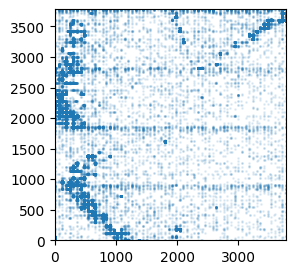

In [9]:
plt.figure(figsize=(12,3))
# detL.PlotDensity(binsize=2,  invert=True);
ax = det.PlotAll(invert=False, s=1, alpha=0.1)
ax.set_aspect("equal", "box")
ax.margins(0,0)
plt.savefig(fileName2Save + 'rawSpike.png', bbox_inches='tight', dpi=300 )

Reading spikes from detection
Fitting dimensionality reduction using all spikes...
...projecting...
...done
Clustering...
Clustering 726181 spikes...
requested -1 cpus
using 8 cpus
number of seeds: 14778
seeds/job: 1848


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   3 out of   8 | elapsed:   38.8s remaining:  1.1min
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:   53.2s finished


Number of estimated units: 3474
# Sampling rate: 19753.775390625.
We have 726181 spikes, only showing  200000


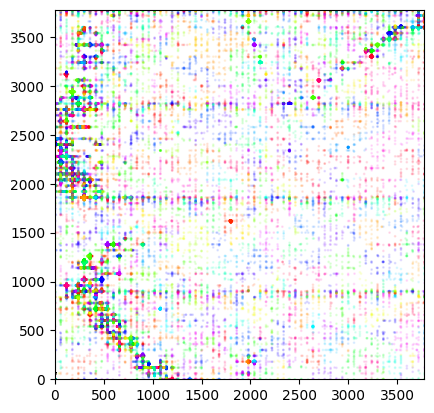

In [10]:
# clustering
Clusters = hs.HSClustering(det)
Clusters.ShapePCA()
Clusters.CombinedClustering(
    alpha=parameters["clustering_alpha"],
    bandwidth=parameters["clustering_bandwidth"],
    bin_seeding=parameters["clustering_bin_seeding"],
    min_bin_freq=parameters["clustering_min_bin_freq"],
    cluster_subset=parameters["clustering_subset"],
    n_jobs=-1)
 
clusterFileName = fileName2Save + "_cluster.hdf5"
# store, this can be read by the HerdingspikesSortingExtractor
Clusters.SaveHDF5(clusterFileName, sampling=rec.get_sampling_frequency())

ax = Clusters.PlotAll(invert=False, s=1, alpha=0.1)
ax.set_aspect("equal", "box")
ax.margins(0,0)
plt.savefig(fileName2Save + 'clusterSpike.png', bbox_inches='tight', dpi=300 )